## Interpreting image regression models with Shapley Additive Explanations

In this notebook we'll use data from the [One Million Impressions dataset](https://github.com/jcpeterson/omi) and common deep learning frameworks to transfer learning from ImageNet ResNets to the task of reproducing human judgements of facial attributes. Then, we'll use [Shapley Additive Explanations](https://shap.readthedocs.io/en/latest/) to explain the trained models' inferences.

## some setup and light preprocessing 


In [1]:
import numpy as np
import pandas as pd
import os
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import shap

In [2]:
#if you want to run this, be sure to clone the OMI repo and point this to its location
omi_dir = ...

face_df = pd.read_csv(os.path.join(omi_dir,'attribute_means.csv'))
img_dir = os.path.join(omi_dir,'images')

#some setup - I scaled the trustworthiness ratings because my MSE was blowing up
face_df['img_filename'] = face_df['stimulus'].apply(lambda x: f'{x}.jpg')
trustworthy_scaler = StandardScaler()
trustworthy_scaler.fit(face_df[:800].trustworthy.values.reshape(-1,1))
face_df['trustworthy_scaled'] = trustworthy_scaler.transform(face_df.trustworthy.values.reshape(-1,1))

## pytorch version

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import torchvision
from torchvision import models
from torch.utils.data import Dataset, DataLoader

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [4]:
class torch_dataset(Dataset):
    def __init__(self, df, attribute, img_dir, transform):
        """
        df        : a dataframe with columns including 'img_filename' and [attribute]
        attribute : the string name of a column in df containing values we'd like to predict
        img_dir   : image directory
        transform : image preprocessing function - in this case, turning the PIL Image into a tensor
        """
        self.df = df
        self.img_dir = img_dir
        self.attribute = attribute
        self.transform = transform
        
    def __len__(self):
        return len(self.df)

    def __getitem__(self,idx):
        img_path = os.path.join(self.img_dir, self.df.iloc[idx].img_filename)
        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)
        
        target = torch.tensor(float(self.df.iloc[idx][self.attribute]))
                
        
        return image, target

In [5]:
base_model = models.resnet18(weights='IMAGENET1K_V1')
imagenet_normalization = models.ResNet18_Weights.DEFAULT.transforms()

In [6]:
train_dataset = torch_dataset(df=face_df[:800],attribute='trustworthy_scaled',img_dir=img_dir,transform=imagenet_normalization)
test_dataset = torch_dataset(df=face_df[800:],attribute='trustworthy_scaled',img_dir=img_dir,transform=imagenet_normalization)

dataloaders = {'train':DataLoader(dataset=train_dataset,batch_size=16,shuffle=True),
               'val':DataLoader(dataset=test_dataset,batch_size=16,shuffle=False)}

In [7]:
def train_model(model, criterion, optimizer, scheduler, num_epochs):
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        
        for phase in ['train','val']:
            running_squared_error = 0.0
            sample_count = 0
            
            if phase == 'train':
                model.train()
            else:
                model.eval()
            
            for inputs, targets in dataloaders[phase]:
                inputs = inputs.to(device)
                targets = targets.to(device)              
                optimizer.zero_grad()
                
                with torch.set_grad_enabled(phase=='train'):
                    outputs = model(inputs).squeeze(-1)
                    loss = criterion(outputs, targets)
                    
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                
                sample_count += targets.size(0)
                running_squared_error += loss.item() * targets.size(0)
                #print(sample_count, running_squared_error)
                
            epoch_loss = running_squared_error / sample_count
            print(f'{phase} MSE: {epoch_loss:.4f}')
                
        scheduler.step()
    
    return model

In [8]:
class generic_resnet(nn.Module):
    def __init__(self,base_model):
        super().__init__()

        base_model_features = base_model.fc.in_features
        base_model.fc = nn.Identity()

        self.base_model = base_model
        self.base_model.requires_grad_(False)

        self.prediction_head = nn.Sequential(nn.Linear(base_model_features,128),
                                         nn.ReLU(),
                                         nn.Linear(128,64),
                                         nn.ReLU(),
                                         nn.Linear(64,32),
                                         nn.ReLU(),
                                         nn.Linear(32,1))
    def forward(self,x):
        x = self.base_model(x)
        return self.prediction_head(x)

    def train(self,mode=True):
        super().train(mode)
        self.base_model.eval()
        return self

In [9]:
trustworthy_model = generic_resnet(base_model).to(device)

In [10]:
criterion = nn.MSELoss()
optimizer = optim.SGD(trustworthy_model.prediction_head.parameters())
scheduler = lr_scheduler.StepLR(optimizer, step_size=3)

In [11]:
trustworthy_model = train_model(trustworthy_model,criterion,optimizer,scheduler,num_epochs=10)

Epoch 1/10
train MSE: 1.0072
val MSE: 0.9628
Epoch 2/10
train MSE: 0.9861
val MSE: 0.9422
Epoch 3/10
train MSE: 0.9659
val MSE: 0.9243
Epoch 4/10
train MSE: 0.9547
val MSE: 0.9226
Epoch 5/10
train MSE: 0.9528
val MSE: 0.9209
Epoch 6/10
train MSE: 0.9510
val MSE: 0.9191
Epoch 7/10
train MSE: 0.9499
val MSE: 0.9190
Epoch 8/10
train MSE: 0.9497
val MSE: 0.9188
Epoch 9/10
train MSE: 0.9495
val MSE: 0.9186
Epoch 10/10
train MSE: 0.9494
val MSE: 0.9186


this is all pretty boilerplate, the gist being that we've transferred learning from some image model to our own data. it's worth pointing out here that this model did not actually learn very much about the task, and that this fact does not stop us from applying SHAP to the uninformed model's predictions. 

## defining a manual prediction function 

the shap Explainer() needs a function like this which recapitulates the process from image input
to model prediction, which means we preprocess, run the actual model, and return an output.

In practice this can be a bit of a hassle since the masker's inpainting function (which we'll see soon) is particular about its inputs. So some degree of input massaging may be necessary to add here even if it wasn't necessary or handled implicitly prior. Here you can see we're explicitly going to float channels-first even though the imagenet_normalization() did that for us before.

In [12]:
def predict(img):

    img_tensor = torch.from_numpy(img).float()
    img_tensor = img_tensor.permute(0,3,1,2)
    img_tensor /= 255.0
    
    img_tensor = imagenet_normalization(img_tensor)
    img_tensor = img_tensor.to(device)
    
    with torch.inference_mode():
        output = trustworthy_model(img_tensor)
    
    return output.cpu().numpy()

## specifying a "masker" and "explainer"

the second argument of the masker should correspond with the input image dimensions. The first argument has to do with how information from the input images will be masked, with Telea inpainting in this case. Then, you make an explainer with your prediction function and your image masker

In [13]:
masker = shap.maskers.Image('inpaint_telea',(1024,1024,3))
explainer = shap.Explainer(predict,masker) 

## running the "explainer" you just specified

when everything is set up, you run the explainer you've set up on a batch of images to calculate shap values for them. NB: "batch_size" here isn't about the number of images for which you're running shap, but the number of masked images concurrently used in the shap calculation for your inputs (which themselves also might be a batch)

max_evals generally dictates the SHAP calculation's resolution at the cost of compute, where the more
evals you run the finer your analysis will be. By default, using this "Image" masker sets the explainer to run "partitionexplainer()", which uses recursive image splits and subsequent hierarchical clustering to partition the image. max_evals governs the extent to which this partition tree is explored i.e., the amount (and therefore resolution) of partitions whose influence on the model output is evaluated. 

if you are using a classification model with multiple labels, you can also set an argument in the
explainer() call to specify which label you want to investigate.

In [14]:
#i'm just running one image here for demonstration's sake but the shap library prefers to work in 
#batches. I insert a batch dimension in the explainer() call for this reason. 
img = np.array(Image.open(os.path.join(img_dir, face_df.iloc[0].img_filename)).convert("RGB"))

#can add a synthetic batch dimension to singleton inputs with [None,...]
shap_values = explainer(img[None,...],max_evals=1000,batch_size=10)

  0%|          | 0/998 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [07:30, 450.21s/it]              


and then the shap library itself comes with a nice plotting function which is very amenable to tinkering if you go into the function itself. If you want to work with the shap values directly, they are in shap_values.values  

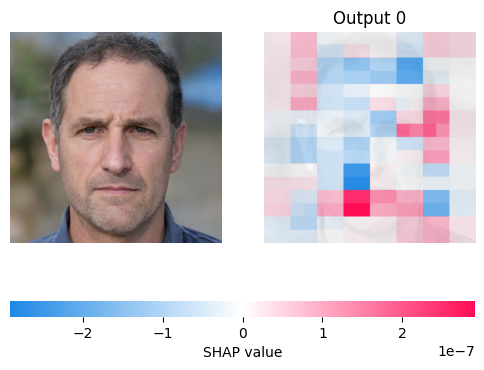

In [15]:
shap.image_plot(
    shap_values=shap_values,
    pixel_values=shap_values.data
)

## tensorflow/keras version

is essentially the same

In [3]:
import keras 
from keras.applications.resnet import preprocess_input
from keras import Sequential, layers
from keras.layers import Dense, Flatten, GlobalAveragePooling2D

In [4]:
class data_generator(keras.utils.Sequence):
    def __init__(self, x, y, shuffle, batch_size):
        self.x, self.y = np.array(x), np.array(y)
        self.shuffle = shuffle
        self.batch_size = batch_size
        self.on_epoch_end()

    def __len__(self):
        return int(np.floor(len(self.x)/self.batch_size))

    def __getitem__(self,idx):
        batch_x = self.x[self.indexes[idx*self.batch_size:(idx+1)*self.batch_size]]
        batch_y = self.y[self.indexes[idx*self.batch_size:(idx+1)*self.batch_size]]
        return preprocess_input(np.array([keras.utils.img_to_array(Image.open(image),dtype='uint8')for image in batch_x])), np.array(batch_y)

    def on_epoch_end(self):
        self.indexes = np.arange(len(self.x))
        if self.shuffle:
            np.random.shuffle(self.indexes)

In [5]:
train_dgen = data_generator(face_df[:800]['img_filename'].apply(lambda x: os.path.join(img_dir,x)),
                            face_df[:800]['trustworthy_scaled'],shuffle=True,batch_size=4)

test_dgen = data_generator(face_df[800:]['img_filename'].apply(lambda x: os.path.join(img_dir,x)),
                           face_df[800:]['trustworthy_scaled'],shuffle=False,batch_size=4)

In [6]:
trustworthy_model = Sequential()
#my keras turns out not to support resnet18, so I used 50 for convenience
#some minor changes ensue but they're not really relevant for the shap workflow 
rn_base = keras.applications.ResNet50(include_top=False,input_shape=(1024,1024,3),weights='imagenet')
rn_base.trainable = False

trustworthy_model.add(rn_base)
trustworthy_model.add(layers.GlobalAveragePooling2D())
trustworthy_model.add(layers.Dense(128,activation='relu'))
trustworthy_model.add(layers.Dense(64,activation='relu'))
trustworthy_model.add(layers.Dense(32, activation='relu'))
trustworthy_model.add(layers.Dense(1,activation='linear'))

In [7]:
trustworthy_model.compile(optimizer='sgd',loss='mse',metrics=['mse'])
trustworthy_model.fit(train_dgen,validation_data=test_dgen,epochs=10)

Epoch 1/10
200/200 [==============================] - 84s 374ms/step - loss: 0.9319 - mse: 0.9319 - val_loss: 0.6600 - val_mse: 0.6600
Epoch 2/10
200/200 [==============================] - 74s 369ms/step - loss: 0.7163 - mse: 0.7163 - val_loss: 0.6050 - val_mse: 0.6050
Epoch 3/10
200/200 [==============================] - 74s 369ms/step - loss: 0.6335 - mse: 0.6335 - val_loss: 0.5245 - val_mse: 0.5245
Epoch 4/10
200/200 [==============================] - 74s 369ms/step - loss: 0.5755 - mse: 0.5755 - val_loss: 0.5760 - val_mse: 0.5760
Epoch 5/10
200/200 [==============================] - 74s 370ms/step - loss: 0.5253 - mse: 0.5253 - val_loss: 0.4827 - val_mse: 0.4827
Epoch 6/10
200/200 [==============================] - 74s 369ms/step - loss: 0.5437 - mse: 0.5437 - val_loss: 0.5399 - val_mse: 0.5399
Epoch 7/10
200/200 [==============================] - 75s 372ms/step - loss: 0.4716 - mse: 0.4716 - val_loss: 0.4916 - val_mse: 0.4916
Epoch 8/10
200/200 [==============================] - 7

In [8]:
def predict(img):    
    img_copy = img.copy()                      #keras' resnet preprocessing function can modify 
    img_prepro = preprocess_input(img_copy)    #numpy arrays in place, so here we need a copy
    return trustworthy_model(img_prepro)       #in exchange, keras' resnet preprocessing function
                                               #plays nice with the shap library expectations

masker = shap.maskers.Image('inpaint_telea',(1024,1024,3))
explainer = shap.Explainer(predict,masker) 

In [9]:
img = np.array(Image.open(os.path.join(img_dir, face_df.iloc[0].img_filename)).convert("RGB"))
shap_values = explainer(img[None,...],max_evals=1000,batch_size=1)

  0%|          | 0/998 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [13:27, 807.63s/it]              


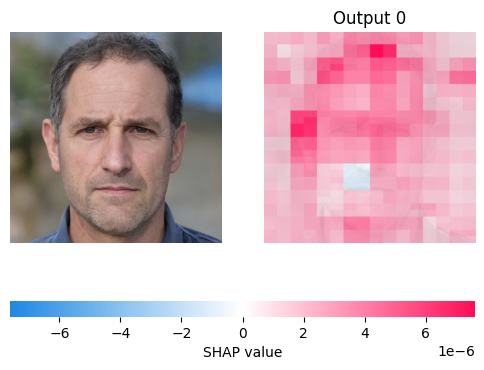

In [10]:
shap.image_plot(
    shap_values=shap_values,
    pixel_values=shap_values.data
)

we can sum the shap base and feature values to verify, expecting them to be equal to the prediction, that shap is working. 

"base value" is the model's prediction for a baseline state defined by the SHAP setup we're using (in this case, something like when the entire image has been masked; but there exist other ways of establishing a baseline). 
Feature values, therefore, are the contributions from each image feature (specifically, coalitions of image partitions; can be abstracted with a few caveats to "regions of the image") in moving the model's actual output relative to that baseline. By default, SHAP depicts features which increase the output relative to baseline in red and features which decrease the model output relative to baseline in blue.

In [11]:
pred = predict(img[None,...])
base = np.asarray(shap_values.base_values).squeeze()
feature_sum = shap_values.values.sum()

print("prediction:       ", pred)
print("shap sums:        ", base + feature_sum)

prediction:        tf.Tensor([[-0.47991055]], shape=(1, 1), dtype=float32)
shap sums:         -0.4799105525016767


and this can help us think about the model's operation: obviously different from the resnet18 version; here, this model seems to exhibit a relatively low baseline prediction and rules about using features to increase it

In [12]:
#we can look at the SHAP baseline in terms of our trustworthiness ratings 
trustworthy_scaler.inverse_transform(base.reshape(1,-1))

array([[20.57333487]])

it's also worth pointing out the fact that SHAP has attributed salience to features nominally unrelated to this task! That is, we set out to model the way people perceive faces, but Shapley explanations of our models' predictions assign value to regions of our image background. 

If we narrowly look to our SHAP calculation itself for an explanation (no pun intended), it could be the case that image partitions which incorporate both relevant (i.e., parts of the face) and ostensibly irrelevant (i.e., parts of the background) aspects of the image are being evaluated together, and if we cranked max_evals high enough we'd obtain a feature map granular enough to avoid this. 

More broadly, it turns out the backgrounds of face images _do_ appear to influence the way we perceive those faces [[citation]](https://pmc.ncbi.nlm.nih.gov/articles/PMC10529556/). If there are actual statistical relationships in our data between an image's background and the ratings it received, then it should come as no surprise that our models learned them. We could imagine testing this idea directly by manipulating the image backgrounds and seeing if our models treat the same faces differently as a result.  

If our goal is to model not properties of the faces but _how humans perceive those properties_, and we have reason to believe that contextual information is a part of that perception, then we might actually want our model to incorporate features of the background in its predicton on a face. This thread takes us far beyond the scope of this demonstration but I hope you'll agree that these kinds of questions are really interesting!